# Load and Explore Data

In [4]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from nltk.stem.porter import PorterStemmer

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

RAW_CSV_DIR = "data/df.csv"
CLEAN_CSV_DIR = "data/cleaned_df.csv"

# load or create clean data
if os.path.exists(CLEAN_CSV_DIR):
    print(f"Found existing cleaned dataset at {CLEAN_CSV_DIR}. Loading instantly...")
    df = pd.read_csv(CLEAN_CSV_DIR)
    
else:
    print(f"Cleaned dataset not found. Loading raw data from {RAW_CSV_DIR}...")
    df = pd.read_csv(RAW_CSV_DIR)
    df = df.dropna(subset=['text'])
    
    ps = PorterStemmer()
    tqdm.pandas()
    
    def clean_spam_text(text):
        if not isinstance(text, str):
            return ""
        return ' '.join([ps.stem(word) for word in text.split()])

    # this take ~15 min
    df['cleaned_text'] = df['text'].progress_apply(clean_spam_text)
    
    df.to_csv(CLEAN_CSV_DIR, index=False)
    print("Saved successfully!")

df = df.dropna(subset=['cleaned_text', 'label'])
df = df[df['cleaned_text'].astype(str).str.strip() != '']

print(f"Shape before dropping duplicates: {df.shape}")

# Drop duplicates based on the cleaned text and the label
df = df.drop_duplicates(subset=['cleaned_text', 'label'], keep='first')

print(f"Dataset ready! Shape: {df.shape}")

Found existing cleaned dataset at data/cleaned_df.csv. Loading instantly...
Shape before dropping duplicates: (365445, 3)
Dataset ready! Shape: (278925, 3)


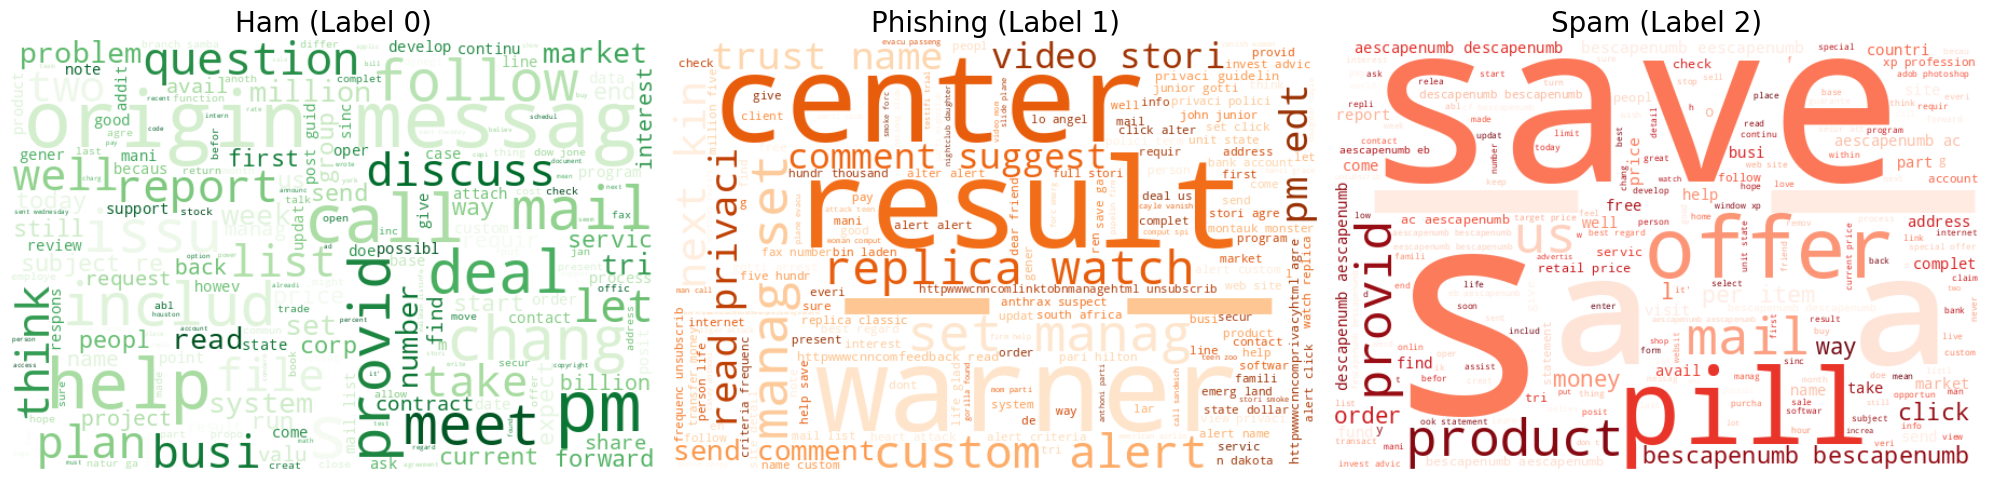

In [5]:

# custom stop words to ignore dataset artifacts and common email words
# usually wordclouds removes stopwords but this is after stemming
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    # dataset artifacts
    'escapenumb', 'escapelong', 'escapenumber', 'escapenumberd', 'escapenumbermg', 'cescapenumb',
    'cabl', 'news', 'daili', 'fri', 'aug', 'wed', 'thu', 'mon', 'tue',
    'top', 'receiv', 'network', 'email', 
    
    # Stemmed English stop words and extremely common non-informative words
    'thi', 'wa', 'ha', 'hi', 'ani', 'onli', 'use', 'will', 'need', 'know', 'make', 
    'one', 'say', 'look', 'go', 'time', 'pleas', 'thank', 'now', 'want', 'said',
    'new', 'may', 'work', 'inform', 'even', 'get', 'see', 'right', 'also', 'much', 'day', 'year',
    
    # Single or short letter noise
    'b', 'x', 'c', 'e', 'u', 'v', 'p', 'lp', 'co', 'com', 'http', 'www',
    
    # Specific Phishing/Ham dump artifacts (CNN, Enron, etc.)
    'compani', 'atlanta', 'georgia', 'cnncom', 'lllp', 'reserv', 'prefer', 
    'enron', 'ect', 'hou', 'cnn', 'stat', 'ethz', 'ch'

    
])

sample_size = 15000

# safely sample the text
df_ham = df[df['label'] == 0]
df_phish = df[df['label'] == 1]
df_spam = df[df['label'] == 2]

ham_sample = df_ham.sample(n=min(sample_size, len(df_ham)), random_state=42)
phish_sample = df_phish.sample(n=min(sample_size, len(df_phish)), random_state=42)
spam_sample = df_spam.sample(n=min(sample_size, len(df_spam)), random_state=42)

ham_text = " ".join(ham_sample['cleaned_text'].astype(str))
phish_text = " ".join(phish_sample['cleaned_text'].astype(str))
spam_text = " ".join(spam_sample['cleaned_text'].astype(str))

wc_ham = WordCloud(width=600, height=400, background_color='white', 
                   colormap='Greens', stopwords=custom_stopwords).generate(ham_text)
wc_phish = WordCloud(width=600, height=400, background_color='white', 
                     colormap='Oranges', stopwords=custom_stopwords).generate(phish_text)
wc_spam = WordCloud(width=600, height=400, background_color='white', 
                    colormap='Reds', stopwords=custom_stopwords).generate(spam_text)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

axs[0].imshow(wc_ham, interpolation='bilinear')
axs[0].set_title('Ham (Label 0)', fontsize=20)
axs[0].axis('off')

axs[1].imshow(wc_phish, interpolation='bilinear')
axs[1].set_title('Phishing (Label 1)', fontsize=20)
axs[1].axis('off')

axs[2].imshow(wc_spam, interpolation='bilinear')
axs[2].set_title('Spam (Label 2)', fontsize=20)
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [6]:
X = df['cleaned_text']
y = df['label'] # 0 -> ham, 1 -> phish, 2 -> spam

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

text_clf = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=2, max_df=0.7)), 
    ('clf', MultinomialNB())
])

print("Training Naive Bayes model...")
text_clf.fit(X_train, y_train)

predictions = text_clf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

Training Naive Bayes model...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     25622
           1       0.79      0.89      0.84      8575
           2       0.94      0.84      0.89     21588

    accuracy                           0.91     55785
   macro avg       0.89      0.90      0.89     55785
weighted avg       0.92      0.91      0.91     55785



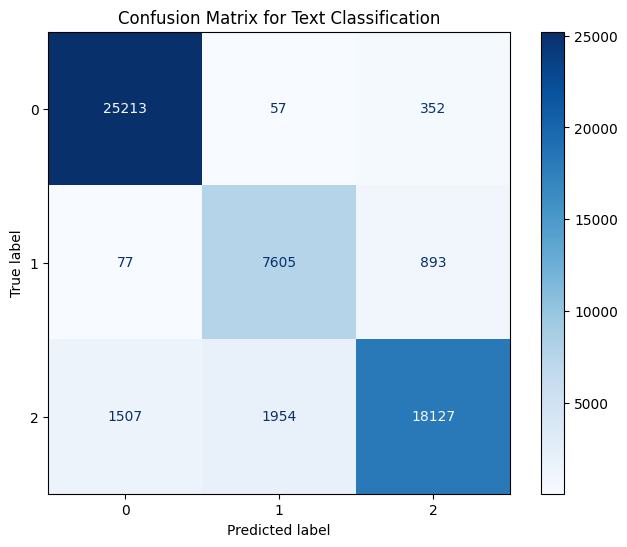

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

_, ax = plt.subplots(figsize=(8, 6))

cmd = ConfusionMatrixDisplay.from_estimator(
    text_clf, 
    X_test, 
    y_test, 
    display_labels=text_clf.classes_,
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix for Text Classification')
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- TF-IDF Representation ---")

# Swap CountVectorizer for TfidfVectorizer
tfidf_clf = Pipeline([
    ('vect', TfidfVectorizer(stop_words='english', min_df=2, max_df=0.7)), 
    ('clf', MultinomialNB())
])

print("Training TF-IDF Naive Bayes...")
tfidf_clf.fit(X_train, y_train)


tfidf_predictions = tfidf_clf.predict(X_test)

print("\n--- TF-IDF Classification Report ---")
print(classification_report(y_test, tfidf_predictions))

--- TF-IDF Representation ---
Training TF-IDF Naive Bayes...

--- TF-IDF Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     25622
           1       0.98      0.57      0.72      8575
           2       0.84      0.93      0.88     21588

    accuracy                           0.90     55785
   macro avg       0.92      0.83      0.85     55785
weighted avg       0.91      0.90      0.89     55785



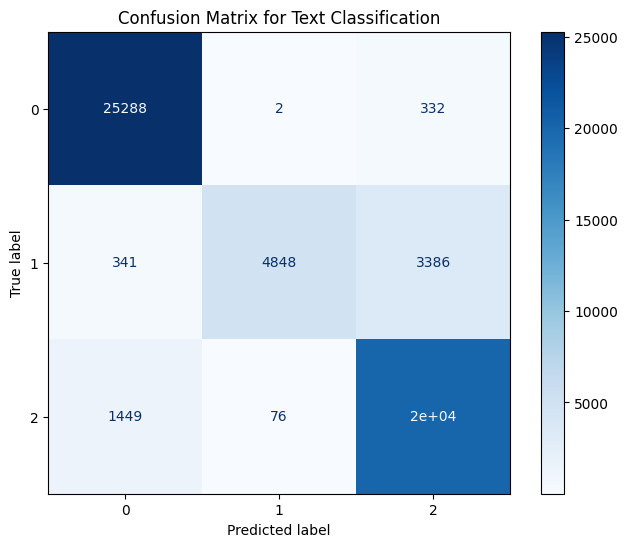

In [9]:
_, ax = plt.subplots(figsize=(8, 6))

cmd = ConfusionMatrixDisplay.from_estimator(
    tfidf_clf, 
    X_test, 
    y_test, 
    display_labels=text_clf.classes_,
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix for Text Classification')
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression

print("--- TF-IDF + Logistic Regression ---")

lr_clf = Pipeline([
    ('vect', TfidfVectorizer(stop_words='english', min_df=2, max_df=0.7)), 
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

print("Training Logistic Regression model...")
lr_clf.fit(X_train, y_train)
lr_predictions = lr_clf.predict(X_test)

print("\n--- LR Classification Report ---")
print(classification_report(y_test, lr_predictions))

--- TF-IDF + Logistic Regression ---
Training Logistic Regression model...

--- LR Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     25622
           1       0.93      0.86      0.89      8575
           2       0.92      0.96      0.94     21588

    accuracy                           0.95     55785
   macro avg       0.95      0.93      0.94     55785
weighted avg       0.95      0.95      0.95     55785



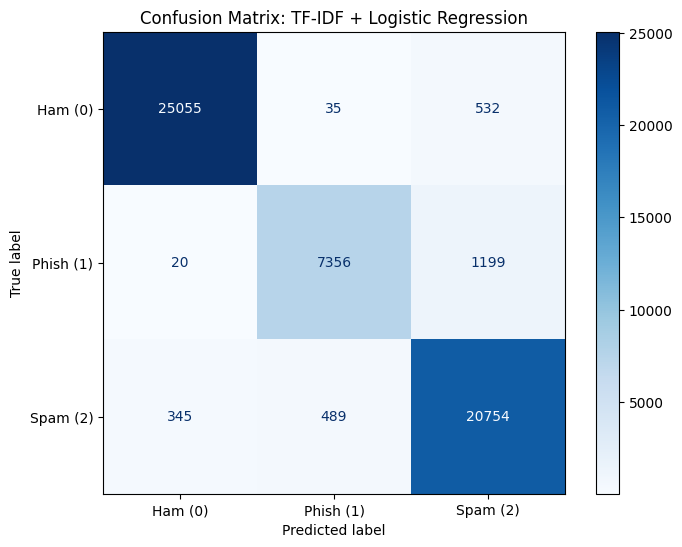

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

cmd = ConfusionMatrixDisplay.from_estimator(
    lr_clf, 
    X_test, 
    y_test, 
    display_labels=['Ham (0)', 'Phish (1)', 'Spam (2)'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix: TF-IDF + Logistic Regression')
plt.show()

In [12]:
import gensim

print("--- Dense Representation (Word2Vec) ---")

# Word2Vec requires a list of words for each email
sentences = [str(text).split() for text in X_train]

print("Training Word2Vec model (this takes a moment)...")
w2v_model = gensim.models.Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# function to average the word vectors for a single email
def get_document_vector(doc):
    words = str(doc).split()
    word_vecs = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if len(word_vecs) == 0:
        return np.zeros(100)
    return np.mean(word_vecs, axis=0)

print("Converting text to dense vectors...")
X_train_dense = np.array([get_document_vector(text) for text in X_train])
X_test_dense = np.array([get_document_vector(text) for text in X_test])

print(f"Dense Feature Space Size: {X_train_dense.shape[1]} dimensions")

print("Training Logistic Regression on Word2Vec embeddings...")
dense_clf = LogisticRegression(max_iter=1000, random_state=42)
dense_clf.fit(X_train_dense, y_train)

dense_predictions = dense_clf.predict(X_test_dense)
print("\n--- Word2Vec + LR Classification Report ---")
print(classification_report(y_test, dense_predictions))

--- Dense Representation (Word2Vec) ---
Training Word2Vec model (this takes a moment)...
Converting text to dense vectors...
Dense Feature Space Size: 100 dimensions
Training Logistic Regression on Word2Vec embeddings...

--- Word2Vec + LR Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     25622
           1       0.92      0.91      0.91      8575
           2       0.92      0.91      0.92     21588

    accuracy                           0.93     55785
   macro avg       0.93      0.93      0.93     55785
weighted avg       0.93      0.93      0.93     55785



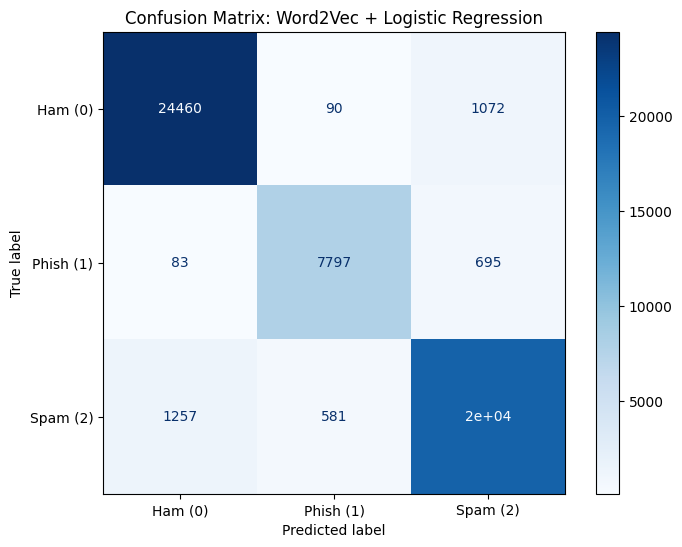

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

cmd = ConfusionMatrixDisplay.from_estimator(
    dense_clf, 
    X_test_dense, 
    y_test, 
    display_labels=['Ham (0)', 'Phish (1)', 'Spam (2)'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix: Word2Vec + Logistic Regression')
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

print("--- Dense Representation + Random Forest ---")

# n_estimators=100 to test
rf_dense = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest on Word2Vec embeddings (this takes some time)...")
rf_dense.fit(X_train_dense, y_train)

rf_dense_predictions = rf_dense.predict(X_test_dense)

print("\n--- Word2Vec + Random Forest Classification Report ---")
print(classification_report(y_test, rf_dense_predictions))

--- Dense Representation + Random Forest ---
Training Random Forest on Word2Vec embeddings (this takes some time)...

--- Word2Vec + Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     25622
           1       0.97      0.93      0.95      8575
           2       0.95      0.96      0.95     21588

    accuracy                           0.96     55785
   macro avg       0.96      0.95      0.96     55785
weighted avg       0.96      0.96      0.96     55785



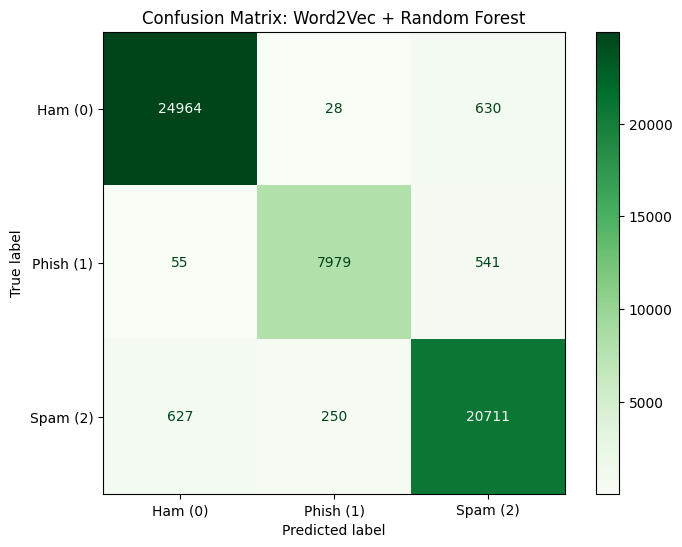

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))


cmd = ConfusionMatrixDisplay.from_estimator(
    rf_dense, 
    X_test_dense, 
    y_test, 
    display_labels=['Ham (0)', 'Phish (1)', 'Spam (2)'],
    cmap=plt.cm.Greens,
    ax=ax
)

plt.title('Confusion Matrix: Word2Vec + Random Forest')
plt.show()

In [ ]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
    ),

    "SVM": LinearSVC(random_state=42)

}

results_bow = []
scoring = {
    'accuracy': 'accuracy',

    'precision_c0': make_scorer(precision_score,
                               labels=[0],
                               average='macro'),

    'recall_c0': make_scorer(recall_score,
                            labels=[0],
                            average='macro'),

    'f1_c0': make_scorer(f1_score,
                        labels=[0],
                        average='macro')
}

for name, model in models.items():
    pipeline = Pipeline([
        ('vectorizer', CountVectorizer(stop_words='english', min_df=2, max_df=0.7)),
        ('scaler', MaxAbsScaler()),
        ('classifier', model),
    ])
    print(f"\nCross Validation for {name}...")
    cv_results = cross_validate(pipeline, X_train, y_train,
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring,
                                n_jobs=-1)

    results_bow.append({
        "Model": name,
        "Accuracy": f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        "F1_Class0": f"{cv_results['test_f1_c0'].mean():.3f} ± {cv_results['test_f1_c0'].std():.3f}",
        "Recall_Class0": f"{cv_results['test_recall_c0'].mean():.3f} ± {cv_results['test_recall_c0'].std():.3f}",
        "Precision_Class0": f"{cv_results['test_precision_c0'].mean():.3f} ± {cv_results['test_precision_c0'].std():.3f}"
    })

results_df = pd.DataFrame(results_bow).set_index("Model")
print("\n=============================")
print("CROSS VALIDATION RESULTS FOR BOW")
print("=============================")

print(results_df.sort_values(by="F1_Class0", ascending=False))


Cross Validation for Naive Bayes...

Cross Validation for Logistic Regression...


In [ ]:
results_tfidf = []
scoring = {
    'accuracy': 'accuracy',

    'precision_c0': make_scorer(precision_score,
                               labels=[0],
                               average='macro',
                               zero_division=0),

    'recall_c0': make_scorer(recall_score,
                            labels=[0],
                            average='macro',
                            zero_division=0),

    'f1_c0': make_scorer(f1_score,
                        labels=[0],
                        average='macro',
                        zero_division=0)
}

for name, model in models.items():
    pipeline = Pipeline([
        ('vectorizer', TfidfVectorizer(stop_words='english', min_df=2, max_df=0.7)),
        ('classifier', model),
    ])
    print(f"\nCross Validation for {name}...")
    cv_results = cross_validate(pipeline, X_train, y_train,
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring,
                                n_jobs=-1)

    results_tfidf.append({
        "Model": name,
        "Accuracy": f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        "F1_Class0": f"{cv_results['test_f1_c0'].mean():.3f} ± {cv_results['test_f1_c0'].std():.3f}",
        "Recall_Class0": f"{cv_results['test_recall_c0'].mean():.3f} ± {cv_results['test_recall_c0'].std():.3f}",
        "Precision_Class0": f"{cv_results['test_precision_c0'].mean():.3f} ± {cv_results['test_precision_c0'].std():.3f}"
    })

results_df = pd.DataFrame(results_tfidf).set_index("Model")
print("\n=============================")
print("CROSS VALIDATION RESULTS FOR TFIDF")
print("=============================")

print(results_df.sort_values(by="F1_Class0", ascending=False))


Cross Validation for Naive Bayes...

Cross Validation for Logistic Regression...

Cross Validation for SVM...

CROSS VALIDATION RESULTS FOR TFIDF
                          Accuracy      F1_Class0  Recall_Class0  \
Model                                                              
SVM                  0.964 ± 0.001  0.990 ± 0.000  0.988 ± 0.001   
Logistic Regression  0.959 ± 0.001  0.983 ± 0.001  0.980 ± 0.001   
Naive Bayes          0.912 ± 0.001  0.964 ± 0.001  0.985 ± 0.000   

                    Precision_Class0  
Model                                 
SVM                    0.991 ± 0.000  
Logistic Regression    0.987 ± 0.000  
Naive Bayes            0.943 ± 0.001  


In [ ]:
best_model_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english', min_df=2, max_df=0.7)),
    ('classifier', LinearSVC(random_state=42))
])

best_model_pipeline.fit(X_train, y_train)

y_pred = best_model_pipeline.predict(X_test)

print("\n=============================")
print("TEST PERFORMANCE RESULTS SVM")
print("=============================\n")
print(classification_report(y_test, y_pred))


TEST PERFORMANCE RESULTS SVM

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     33709
           1       0.96      0.82      0.88      8626
           2       0.94      0.98      0.96     30754

    accuracy                           0.97     73089
   macro avg       0.96      0.93      0.94     73089
weighted avg       0.97      0.97      0.97     73089



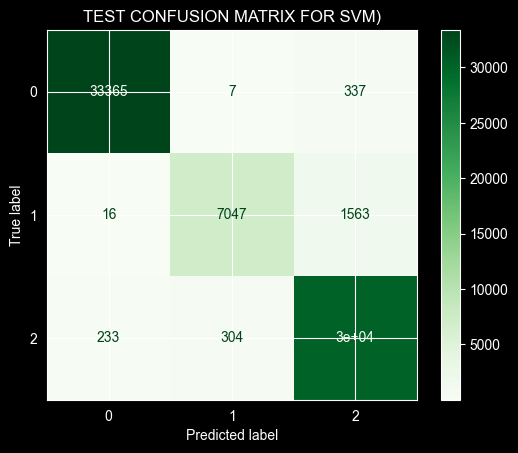

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=best_model_pipeline.classes_,
    cmap='Greens'
)
plt.title('TEST CONFUSION MATRIX FOR SVM)')
plt.show()

